# Laboratorium: Optymalizacja i Metoda Lagrange'a

### Zadanie 1: Empiryczne poszukiwanie minimum (Grid Search) [2 pkt]
Z wykładu wiemy, że TE, SE i ME mają swoje minima odpowiednio w medianie, średniej i środku zakresu. Zweryfikujmy to siłowo.
1. Wygeneruj losową tablicę $X$ składającą się z 50 liczb z przedziału $[-10, 10]$.
2. Napisz trzy funkcje w Pythonie obliczające błąd sumaryczny (TE), kwadratowy (SE) i maksymalny (ME) dla zadanego $X$ i skalarnego punktu $w$.
3. Stwórz gęstą "siatkę" (np. 1000 punktów) potencjalnych wartości $w$ na przedziale $[-10, 10]$ (użyj `np.linspace`).
4. Oblicz wartości wszystkich trzech funkcji straty dla każdego punktu na siatce i znajdź indeksy, dla których błąd jest najmniejszy (użyj `np.argmin`). Wykaż, że wyliczone w ten sposób optymalne $w$ pokrywają się z `np.median`, `np.mean` oraz środkiem zakresu.

In [ ]:
import numpy as np

RANGE_MIN = -10
MAX_RANGE = 10

np.random.seed(2137)
X = np.random.uniform(RANGE_MIN, MAX_RANGE, (50))

def TotalError(X, w):
    return np.sum(np.abs(X - w))

def SquaredError(X, w):
    return np.sum((X - w) ** 2)

def MaximumError(X, w):
    return np.max(np.abs(X - w))

W_grid = np.linspace(RANGE_MIN, MAX_RANGE, 1000)
TE_values = [TotalError(X, w) for w in W_grid]
SE_values = [SquaredError(X, w) for w in W_grid]
ME_values = [MaximumError(X, w) for w in W_grid]

TE_opt_index = np.argmin(TE_values)
TE_opt_value = W_grid[TE_opt_index]
SE_opt_index = np.argmin(SE_values)
SE_opt_value = W_grid[SE_opt_index]
ME_opt_index = np.argmin(ME_values)
ME_opt_value = W_grid[ME_opt_index]

Median_opt_value = np.median(X)
Mean_opt_value = np.mean(X)
Middle_opt_value = (np.max(X) + np.min(X)) / 2

print(f"Optimal w for Total Error: {TE_opt_value}")
print(f"Optimal w for Squared Error: {SE_opt_value}")
print(f"Optimal w for Maximum Error: {ME_opt_value}")
print(f"Optimal w for Median: {Median_opt_value}")
print(f"Optimal w for Mean: {Mean_opt_value}")
print(f"Optimal w for Middle: {Middle_opt_value}")

Optimal w for Total Error: 2.4124124124124116
Optimal w for Squared Error: 1.391391391391391
Optimal w for Maximum Error: 0.07007007007007005
Optimal w for Median: 2.518761201192902
Optimal w for Mean: 1.390682520218924
Optimal w for Middle: 0.06632605616123222


### Zadanie 2: Odporność na wartości odstające (Outliers) [2 pkt]
Zbadajmy, jak bardzo pojedynczy błąd w danych psuje nasz optymalny model.
1. Wygeneruj zbiór $X$ składający się z 30 punktów skupionych wokół zera (np. z rozkładu normalnego).
2. Dodaj na koniec tego zbioru jedną wartość równą $100$ (outlier).
3. Użyj funkcji `scipy.optimize.minimize` (zaczynając od $w_0=0$), aby zminimalizować na nowym zbiorze funkcje TE oraz SE.
4. Wyświetl wyniki i napisz w komentarzu krótki wniosek: dlaczego jedna z tych funkcji niemal zignorowała punkt $100$, podczas gdy druga drastycznie przesunęła swoje minimum? Z czego to wynika matematycznie?

In [ ]:
import numpy as np
import scipy as sp

np.random.seed(2137)
X = np.random.normal(loc=0, scale=1, size=30)

X = np.append(X, 100)

def TotalError(X, w):
    return np.sum(np.abs(X - w))

def SquaredError(X, w):
    return np.sum((X - w) ** 2)

W0 = 0

Result_TE = sp.optimize.minimize(lambda w: TotalError(X, w), W0)
W_TE = Result_TE.x[0]

Result_SE = sp.optimize.minimize(lambda w: SquaredError(X, w), W0)
W_SE = Result_SE.x[0]

print(f"Optimal w for Total Error: {W_TE}")
print(f"Optimal w for Squared Error: {W_SE}")

#Funkcja straty SE, karze bardziej odległe punkty (Ze względu na funkcje kwadratową), dlatego jest bardziej wrażliwa na wartości odstające (outliers) niż TE.

Optimal w for Total Error: 0.2653123046551367
Optimal w for Squared Error: 3.170923340939569


### Zadanie 3: Ważony Błąd Kwadratowy (WSE) [2 pkt]
Wyobraź sobie, że nasze punkty danych nie są równie wiarygodne – każdy element $x_i$ ma przypisaną wagę $v_i > 0$. Definiujemy ważony błąd kwadratowy: 
$$WSE(w) = \sum_{i=1}^n v_i (x_i - w)^2$$
1. Na kartce wyznacz pochodną $\frac{d}{dw} WSE(w)$, przyrównaj ją do zera i wyprowadź analityczny wzór na optymalne $w$ (będzie to tzw. średnia ważona).
2. Zaimplementuj ten wzór w Pythonie.
3. Wygeneruj losowe $X$ i losowe wagi $V$. Oblicz optimum ze swojego wzoru. Następnie zminimalizuj funkcję numerycznie (np. przez Grid Search z Zadania 1 lub `scipy.optimize`) i pokaż, że wyniki są identyczne.

In [11]:
import numpy as np
import scipy as sp

np.random.seed(2137)

X = np.random.uniform(-10, 10, (50))
V = np.random.uniform(0.1, 1.0, (50))

W_opt = np.sum(V * X) / np.sum(V)

def WeightedSquaredError(X, w, V):
    return np.sum(V * (X - w) ** 2)

Result_WSE = sp.optimize.minimize(lambda w: WeightedSquaredError(X, w, V), 0)
W_WSE = Result_WSE.x[0]
print(f"Perfect w for Weighted Squared Error: {W_opt}")
print(f"Optimal w for Weighted Squared Error: {W_WSE}")

Perfect w for Weighted Squared Error: 1.2557950682134498
Optimal w for Weighted Squared Error: 1.2557950463958025


### Zadanie 4: Asymetryczna funkcja straty (Pinball Loss) [2 pkt]
Funkcja TE (mediana) karze tak samo za błędy przeszacowania, jak i niedoszacowania. W regresji kwantylowej używa się funkcji asymetrycznej (Pinball Loss):
$L_\tau(x, w) = \begin{cases} \tau(x - w) & \text{jeśli } x \ge w \\ (\tau - 1)(x - w) & \text{jeśli } x < w \end{cases}$
1. Zaimplementuj funkcję całkowitej straty $J(w) = \sum L_\tau(x_i, w)$ dla zadanego zbioru $X$ oraz progu $\tau \in (0, 1)$.
2. Dla losowego zbioru $1000$ punktów i $\tau = 0.90$, użyj `scipy.optimize.minimize_scalar` aby znaleźć optymalne $w$.
3. Udowodnij (korzystając z `np.percentile`), że asymetryczna funkcja straty znalazła dokładnie 90. percentyl Twoich danych.

In [ ]:
import numpy as np
import scipy as sp

np.random.seed(2137)
X = np.random.normal(0, 1, 1000)
Tau = 0.9

def PinballLoss(X, w, tau):
    return np.sum(np.where(X >= w, tau * (X - w), (1 - tau) * (w - X)))

Result_PL = sp.optimize.minimize_scalar(lambda w: PinballLoss(X, w, Tau))
Optimal_W_PL = Result_PL.x
Perfect_W_PL = np.percentile(X, Tau * 100)

print(f"Perfect w for Pinball Loss (tau={Tau}): {Perfect_W_PL}")
print(f"Optimal w for Pinball Loss (tau={Tau}): {Optimal_W_PL}")

Perfect w for Pinball Loss (tau=0.9): 1.3360387046036786
Optimal w for Pinball Loss (tau=0.9): 1.3534226534963671


### Zadanie 5: Analityczny gradient i szukanie punktów krytycznych [2 pkt]
Dana jest funkcja: $f(x, y) = x^2 + 2y^2 - 4x + 4y + 6$.
1. Wylicz analitycznie (na kartce) pochodne cząstkowe $\frac{\partial f}{\partial x}$ oraz $\frac{\partial f}{\partial y}$.
2. Napisz w Pythonie funkcję `grad_f(x, y)`, która zwraca listę dwóch wartości reprezentujących wektor gradientu w zadanym punkcie.
3. Ponieważ w punkcie krytycznym wektor gradientu jest wektorem zerowym, rozwiąż w Pythonie układ dwóch równań: `grad_f(x, y) == [0, 0]`. Użyj do tego funkcji `scipy.optimize.fsolve`. 
4. Oblicz wartość funkcji w znalezionym punkcie.

In [11]:
import numpy as np
import scipy as sp

def f(x, y):
    return x ** 2 + 2 * y ** 2 - 4 * x + 4 * y + 6

def Grad_f(x, y):
    return np.array([2 * x - 4, 4 * y + 4])

Solve_Vector = sp.optimize.fsolve(lambda vars: Grad_f(vars[0], vars[1]), [0, 0])
Result = f(Solve_Vector[0], Solve_Vector[1])

print(f"Optimal point (x, y): ({Solve_Vector[0]}, {Solve_Vector[1]})")
print(f"Function value at optimal point: {Result}")

Optimal point (x, y): (2.0, -1.0)
Function value at optimal point: 0.0


### Zadanie 6: Wizualizacja pola wektorowego gradientu [2 pkt]
Dla funkcji z Zadania 5 (oraz znalezionego minimum):
1. Wygeneruj mapę poziomic (Contour Plot) korzystając z `plt.contour` na siatce punktów $x \in [-2, 6]$, $y \in [-4, 2]$.
2. Wykorzystaj funkcję `plt.quiver`, aby narysować pole wektorowe gradientu (strzałki pokazujące kierunek najszybszego wzrostu funkcji).
3. Zaznacz czerwoną kropką znalezione w Zadaniu 5 minimum. Zaobserwuj i opisz, jak zachowują się strzałki gradientu wokół tego punktu.

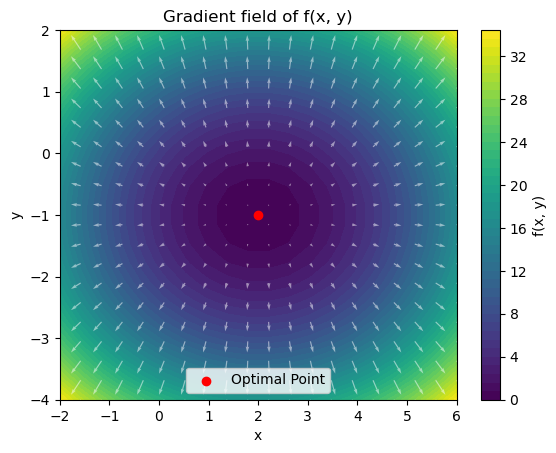

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def f(x, y):
    return x ** 2 + 2 * y ** 2 - 4 * x + 4 * y + 6

def Grad_f(x, y):
    return np.array([2 * x - 4, 4 * y + 4])

x = np.linspace(-2, 6, 20)
y = np.linspace(-4, 2, 20)
X, Y = np.meshgrid(x, y)

Z = f(X, Y)
U, V = Grad_f(X, Y)

plt.contourf(X, Y, Z, levels=50, cmap='viridis')
plt.colorbar(label='f(x, y)')
plt.quiver(X, Y, U, V, color='white', alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient field of f(x, y)')
plt.scatter(2, -1, color='red', label='Optimal Point')
plt.legend()
plt.show()


### Zadanie 7: Regresja liniowa jako minimalizacja funkcji 2-wymiarowej [2 pkt]
Zbudujmy własny model uczenia maszynowego bez używania gotowych bibliotek. Chcemy dopasować prostą $\hat{y} = w_1 x + w_0$ do punktów.
1. Wygeneruj 50 punktów wg wzoru $y_i = 3.5 x_i - 2.0 + \text{szum}$.
2. Napisz funkcję błędu średniokwadratowego $MSE(W)$, która przyjmuje wektor wag $W = [w_0, w_1]$ i oblicza błąd modelu dla całego zbioru danych.
3. Użyj `scipy.optimize.minimize` (przekazując funkcję MSE i początkowe zgadywane wagi $[0, 0]$), aby znaleźć optymalne $w_0$ i $w_1$.
4. Narysuj wykres punktowy wygenerowanych danych oraz poprowadź przez nie znalezioną optymalną prostą.

Optimal parameters: w0 = -1.6593287275895459, w1 = 3.221490916943694


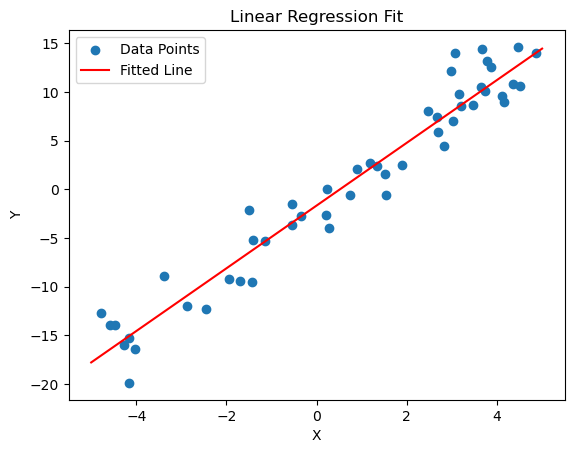

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

np.random.seed(2137)
X = np.random.uniform(-5, 5, 50)
szum = np.random.normal(0, 2.5, 50)
Y = 3.5 * X - 2.0 + szum

def MeanSquaredError(Params):
    a, b = Params
    Y_pred = a * X + b
    return np.mean((Y - Y_pred) ** 2)

Optimal_W_MSE = sp.optimize.minimize(MeanSquaredError, [0, 0])
w1_opt, w0_opt = Optimal_W_MSE.x

print(f"Optimal parameters: w0 = {w0_opt}, w1 = {w1_opt}")

plt.scatter(X, Y, label='Data Points')
x_line = np.linspace(-5, 5, 100)
y_line = w1_opt * x_line + w0_opt
plt.plot(x_line, y_line, color='red', label='Fitted Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()


### Zadanie 8: Maksymalizacja pola pod ograniczeniem (Klasyka) [2 pkt]
Rolnik ma $100$ metrów bieżących ogrodzenia i chce zbudować prostokątny wybieg o maksymalnym polu.
Funkcja celu: $f(x, y) = x \cdot y$. Ograniczenie (obwód): $g(x, y) = 2x + 2y - 100 = 0$.
1. Ułóż ręcznie funkcję Lagrange'a $\mathcal{L}(x, y, \lambda) = f(x, y) - \lambda g(x, y)$.
2. Wyznacz analitycznie trzy pochodne cząstkowe ($\frac{\partial \mathcal{L}}{\partial x}, \frac{\partial \mathcal{L}}{\partial y}, \frac{\partial \mathcal{L}}{\partial \lambda}$).
3. Zaimplementuj ten układ 3 równań jako funkcję w Pythonie, która zwraca listę błędów (dla optymalnego punktu powinny wynosić zero).
4. Rozwiąż ten układ za pomocą `scipy.optimize.fsolve` podając początkowe przybliżenie (np. `x0=[10, 10, 1]`) i podaj optymalne wymiary.

In [1]:
import scipy as sp

def equations(vars):
    x, y, l = vars

    eq1 = y - 2 * l
    eq2 = x - 2 * l
    eq3 = 100 - 2 * x - 2 * y
    
    return [eq1, eq2, eq3]

result = sp.optimize.fsolve(equations, [10, 10, 1])
x_opt, y_opt, lambda_opt = result

print(f"Optymalny wymiar x: {x_opt}")
print(f"Optymalny wymiar y: {y_opt}")
print(f"Maksymalne pole: {x_opt * y_opt}")

Optymalny wymiar x: 25.0
Optymalny wymiar y: 25.0
Maksymalne pole: 625.0


### Zadanie 9: Rzutowanie punktu na płaszczyznę w przestrzeni 3D [2 pkt]
Szukamy punktu $(x, y, z)$ na płaszczyźnie $2x - y + z = 4$, który znajduje się najbliżej początku układu współrzędnych $(0,0,0)$.
Aby uprościć pochodne, minimalizujemy kwadrat odległości: $f(x, y, z) = x^2 + y^2 + z^2$. Ograniczenie to równanie płaszczyzny.
1. Zbuduj funkcję Lagrange'a (będzie mieć 4 zmienne: $x, y, z, \lambda$).
2. Wyznacz na kartce pochodne i zaimplementuj odpowiadający im układ 4 równań w Pythonie.
3. Rozwiąż układ wykorzystując `fsolve`. Wypisz znalezione współrzędne najkrótszego wektora.

In [ ]:
import scipy as sp

def equations(vars):
    x, y, z, l = vars
    
    eq1 = 2 * x - 2 * l
    eq2 = 2 * y + l
    eq3 = 2 * z - l
    eq4 = 4 - 2 * x + y - z
    
    return [eq1, eq2, eq3, eq4]

result = sp.optimize.fsolve(equations, [1, 1, 1, 1])
x_opt, y_opt, z_opt, lambda_opt = result

print(f"Najbliższy punkt na płaszczyźnie:")
print(f"x = {x_opt:.3f}")
print(f"y = {y_opt:.3f}")
print(f"z = {z_opt:.3f}")

Najbliższy punkt na płaszczyźnie:
x = 1.333
y = -0.667
z = 0.667


### Zadanie 10: Geometryczna ilustracja równoległości gradientów [2 pkt]
Główna idea metody stanowi, że w ekstremum gradient funkcji $\nabla f(x)$ musi być równoległy do gradientu ograniczenia $\nabla g(x)$. Zobrazujmy to dla funkcji $f(x, y) = x^2 + y^2$ (paraboloida) przy ograniczeniu liniowym $g(x, y) = x + y - 1 = 0$.
1. Wygeneruj mapę poziomic (contour plot) dla funkcji $f(x, y)$.
2. Narysuj na tym samym wykresie prostą ograniczenia $x + y = 1$.
3. Za pomocą metody z wykładu wiemy, że ekstremum znajduje się w punkcie $(0.5, 0.5)$. Zaznacz go wyraźnie na wykresie.
4. Oblicz analitycznie wektory $\nabla f$ oraz $\nabla g$ w tym punkcie. Narysuj z punktu $(0.5, 0.5)$ dwie strzałki (`plt.quiver`) reprezentujące te wektory. Udowodnij graficznie, że leżą one na tej samej prostej (są współliniowe).

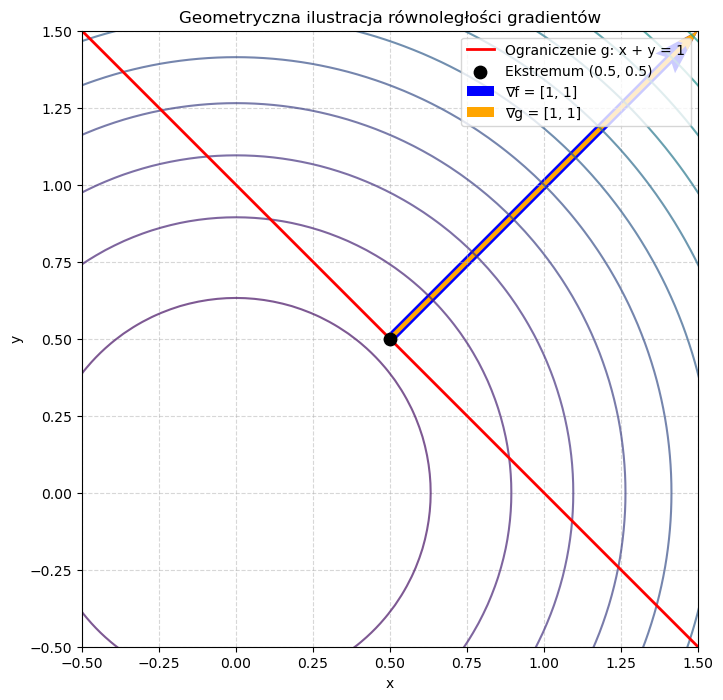

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 2, 100)
y = np.linspace(-1, 2, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

plt.figure(figsize=(8, 8))
contour = plt.contour(X, Y, Z, levels=20, cmap='viridis', alpha=0.7)

x_line = np.linspace(-1, 2, 100)
y_line = 1 - x_line
plt.plot(x_line, y_line, color='red', linewidth=2, label='Ograniczenie g: x + y = 1')

x_opt, y_opt = 0.5, 0.5
plt.scatter(x_opt, y_opt, color='black', zorder=5, s=80, label='Ekstremum (0.5, 0.5)')

plt.quiver(x_opt, y_opt, 1, 1, angles='xy', scale_units='xy', scale=1, 
           color='blue', width=0.015, label='∇f = [1, 1]')
plt.quiver(x_opt, y_opt, 1, 1, angles='xy', scale_units='xy', scale=1, 
           color='orange', width=0.007, label='∇g = [1, 1]')

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Geometryczna ilustracja równoległości gradientów')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()